In [1]:
# Resolve project paths when launched from the root or a project subfolder.
from pathlib import Path

PROJECT_ROOT = next(
    (p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
     if (p / "trial_manifest.json").is_file() and (p / "analysis").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Launch this notebook from the new G&P project folder or analysis folder.")
DATA_ROOT = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
# CELL 1 — Setup for gait EDA

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_ROOT = PROJECT_ROOT / "data"

PEOPLE = [
    "Buddhini",
    "Harshika",
    "Muthuni",
    "Nadeera",
    "Thenuri"
]

print("Dataset root:", DATA_ROOT)

for person in PEOPLE:
    print(
        f"{person:10s}",
        "FOUND" if (DATA_ROOT / person).exists() else "NOT FOUND"
    )

C:\Users\MSI\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Dataset root: C:\Users\MSI\OneDrive\Desktop\Gait and Posture\new G&P\data
Buddhini   FOUND
Harshika   FOUND
Muthuni    FOUND
Nadeera    FOUND
Thenuri    FOUND


In [3]:
# CELL 2 — Find usable limb_angle_mode.csv files

records = []

for person in PEOPLE:

    person_path = DATA_ROOT / person

    for file in person_path.rglob("limb_angle_mode.csv"):

        relative = file.relative_to(person_path)
        parts = relative.parts

        trial = parts[0]

        phase_folder = parts[1] if len(parts) > 1 else ""

        if "Phase_" in phase_folder:
            phase = phase_folder.split("Phase_")[-1]
        else:
            phase = "UNKNOWN"

        df = pd.read_csv(file)

        periodic = df[
            (df["segment_label"] == "periodic") &
            (df["cycle_index"] >= 0)
        ]

        cycles = periodic["cycle_index"].nunique()

        # Only keep recordings containing valid gait cycles
        if cycles > 0:

            records.append({
                "person": person,
                "trial": trial,
                "phase": phase,
                "cycles": cycles,
                "path": str(file)
            })


usable_files = pd.DataFrame(records)

usable_files["trial_num"] = pd.to_numeric(
    usable_files["trial"],
    errors="coerce"
)

usable_files = (
    usable_files
    .sort_values(["person", "trial_num", "phase"])
    .drop(columns="trial_num")
    .reset_index(drop=True)
)

display(usable_files)

print("\nUsable files:", len(usable_files))

print(
    "Independent person-trial combinations:",
    usable_files[["person", "trial"]]
    .drop_duplicates()
    .shape[0]
)

,person,trial,phase,cycles,path
0,Buddhini,1,02,10,C:\Users\MSI\OneDrive\Desktop\Gait and Posture...
1,Buddhini,2,02,15,C:\Users\MSI\OneDrive\Desktop\Gait and Posture...
2,Buddhini,3,02,9,C:\Users\MSI\OneDrive\Desktop\Gait and Posture...
3,Buddhini,4,02,9,C:\Users\MSI\OneDrive\Desktop\Gait and Posture...
4,Buddhini,7,01,16,C:\Users\MSI\OneDrive\Desktop\Gait and Posture...
5,Buddhini,9,02,18,C:\Users\MSI\OneDrive\Desktop\Gait and Posture...
6,Harshika,1,02,10,C:\Users\MSI\OneDrive\Desktop\Gait and Posture...
7,Harshika,2,01,11,C:\Users\MSI\OneDrive\Desktop\Gait and Posture...
8,Harshika,2,02,10,C:\Users\MSI\OneDrive\Desktop\Gait and Posture...
9,Harshika,3,02,9,C:\Users\MSI\OneDrive\Desktop\Gait and Posture...



Usable files: 28
Independent person-trial combinations: 22


Extract And Normalize Gait cycles

In [4]:
# CELL 3 — Extract and normalize gait cycles to 0–100%

ORIGINAL_ANGLE_COLS = [
    "left_ankle_to_foot_original_angle",
    "left_elbow_to_wrist_original_angle",
    "left_hip_to_knee_original_angle",
    "left_knee_to_ankle_original_angle",
    "left_shoulder_to_elbow_original_angle",
    "left_wrist_to_hand_original_angle",
    "mid_to_upper_spine_original_angle",
    "neck_to_left_shoulder_original_angle",
    "neck_to_right_shoulder_original_angle",
    "pelvis_to_left_hip_original_angle",
    "pelvis_to_lower_spine_original_angle",
    "pelvis_to_right_hip_original_angle",
    "right_ankle_to_foot_original_angle",
    "right_elbow_to_wrist_original_angle",
    "right_hip_to_knee_original_angle",
    "right_knee_to_ankle_original_angle",
    "right_shoulder_to_elbow_original_angle",
    "right_wrist_to_hand_original_angle"
]

TARGET_POINTS = 101
target_percent = np.linspace(0, 100, TARGET_POINTS)

normalized_cycles = []

for _, file_row in usable_files.iterrows():

    df = pd.read_csv(file_row["path"])

    periodic = df[
        (df["segment_label"] == "periodic") &
        (df["cycle_index"] >= 0)
    ].copy()

    for cycle_id, cycle_df in periodic.groupby("cycle_index"):

        cycle_df = cycle_df.sort_values("time")

        # Need at least 2 points for interpolation
        if len(cycle_df) < 2:
            continue

        original_percent = np.linspace(
            0,
            100,
            len(cycle_df)
        )

        normalized = {
            "person": file_row["person"],
            "trial": file_row["trial"],
            "phase": file_row["phase"],
            "cycle": cycle_id
        }

        # Keep actual cycle duration separately
        normalized["duration"] = (
            cycle_df["time"].iloc[-1]
            - cycle_df["time"].iloc[0]
        )

        for signal in ORIGINAL_ANGLE_COLS:

            values = cycle_df[signal].to_numpy()

            normalized[signal] = np.interp(
                target_percent,
                original_percent,
                values
            )

        normalized_cycles.append(normalized)

print("Normalized cycles:", len(normalized_cycles))

Normalized cycles: 435


In [5]:
# CELL 4 — Check normalized cycles

print("People:", sorted(
    set(c["person"] for c in normalized_cycles)
))

print("\nCycles per person:")

for person in PEOPLE:
    n = sum(
        c["person"] == person
        for c in normalized_cycles
    )

    print(f"{person:10s}: {n}")

print("\nExample:")
example = normalized_cycles[0]

print("Person:", example["person"])
print("Trial:", example["trial"])
print("Phase:", example["phase"])
print("Cycle:", example["cycle"])
print("Duration:", example["duration"])

print(
    "Points in signal:",
    len(example["left_hip_to_knee_original_angle"])
)

People: ['Buddhini', 'Harshika', 'Muthuni', 'Nadeera', 'Thenuri']

Cycles per person:
Buddhini  : 77
Harshika  : 59
Muthuni   : 30
Nadeera   : 124
Thenuri   : 145

Example:
Person: Buddhini
Trial: 1
Phase: 02
Cycle: 1
Duration: 1.2900000000000005
Points in signal: 101


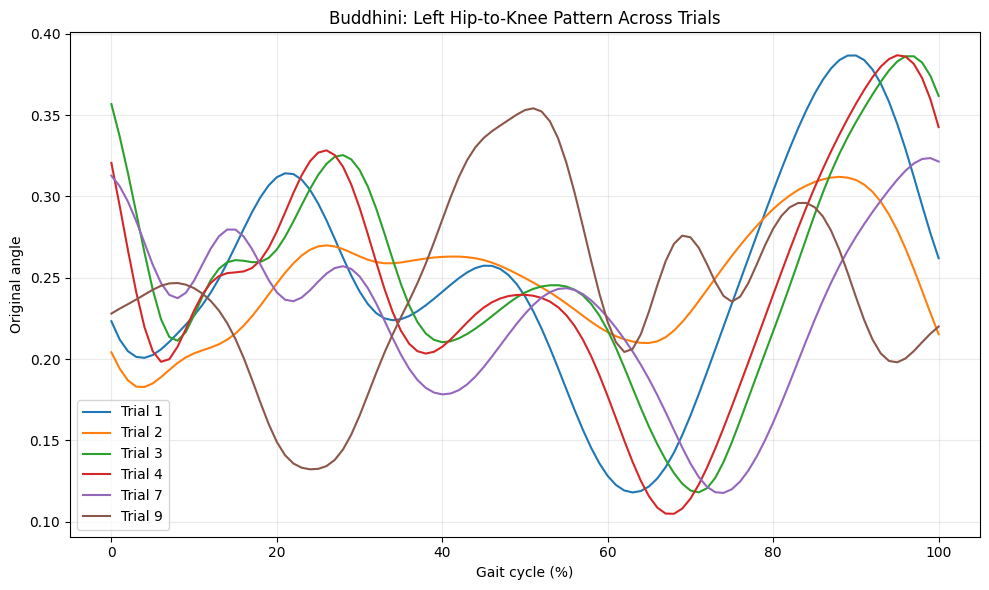

In [6]:
# CELL 5 — Compare one person's gait across independent trials

PERSON = "Buddhini"
SIGNAL = "left_hip_to_knee_original_angle"

plt.figure(figsize=(10, 6))

trials = sorted(
    set(
        c["trial"]
        for c in normalized_cycles
        if c["person"] == PERSON
    ),
    key=int
)

for trial in trials:

    trial_cycles = [
        c[SIGNAL]
        for c in normalized_cycles
        if c["person"] == PERSON
        and c["trial"] == trial
    ]

    if len(trial_cycles) == 0:
        continue

    trial_cycles = np.vstack(trial_cycles)

    # Mean waveform for this independent trial
    mean_waveform = trial_cycles.mean(axis=0)

    plt.plot(
        target_percent,
        mean_waveform,
        label=f"Trial {trial}"
    )

plt.xlabel("Gait cycle (%)")
plt.ylabel("Original angle")
plt.title(
    f"{PERSON}: Left Hip-to-Knee Pattern Across Trials"
)

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Buddhini shows some repeatable structure across trials, but the left hip-to-knee signal is not highly consistent across all six independent trials. There is substantial trial-to-trial variation.
Remember that each line is the average of all normalized gait cycles within one independent trial, not a single gait cycle.

Trials 1, 3, and 4 look particularly similar. They have roughly the same overall structure: an early peak around 20–30%, a decrease through the middle of the cycle, a pronounced trough around 65–70%, and a large late-cycle peak around 90–97%.
That's encouraging because those recordings were collected independently, yet a similar waveform appears.

Trial 7 also follows some of that structure, especially the mid/late-cycle trough and subsequent rise, although its amplitude and timing differ.
But Trials 2 and 9 are noticeably different. Trial 2 has a much shallower late-cycle trough and smaller final peak. Trial 9 is the biggest standout: it has a very large peak around the middle (~50%) and then another local peak around ~70%, while the other trials generally show their major trough around that region.

So visually, we can think of it as:
Trials 1, 3, 4  → strongly similar shape
Trial 7          → moderately similar
Trial 2          → weaker similarity
Trial 9          → substantially different shape


Why could the same person's trials differ?
There are several plausible explanations

1. Natural gait variability. A person's walking isn't perfectly identical every time. Speed, stride length, fatigue, attention, arm movement, starting position, and other factors can alter the measured waveform.
2. Phase alignment may not represent the same biomechanical event. This is a big one. We resampled every annotated cycle to 0–100%, but our code assumes that cycle_index boundaries correspond to comparable points in the gait cycle.
If one cycle begins around heel strike while another effectively begins at a different part of the movement, two physically similar waveforms can appear phase shifted. Trial 9 makes me especially interested in checking this.
3. Your signal may not be a conventional anatomical joint angle. left_hip_to_knee_original_angle is the name of the exported signal, but we haven't established its exact reference frame and physical definition. That's why we shouldn't interpret a value such as 0.35 as a conventional hip angle yet. The earlier data review explicitly warned about this.    Pasted text
4. Recording/session variation. Sensor placement/orientation, calibration, clothing, attachment position, or recording conditions could shift the signal between trials. A person classifier could unfortunately learn these session/device artifacts instead of gait identity if we're not careful.
5. Averaging can hide within-trial variability. Each colored curve is a mean. For example, Trial 1's cycles might individually vary a lot even though their average looks smooth. We currently can't see that.
And there's another issue I want us to investigate before drawing conclusions.
The curves don't line up perfectly in phase
Look around 60–75%.
Trials 1, 3, 4 and 7 generally descend into a trough. Trial 9 behaves very differently there.
That could mean:
Trial 9 contains genuinely different measured movement.



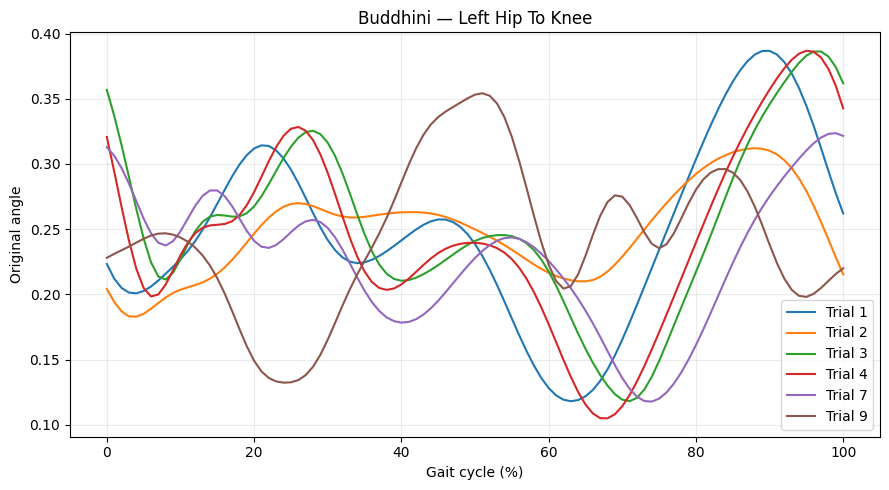

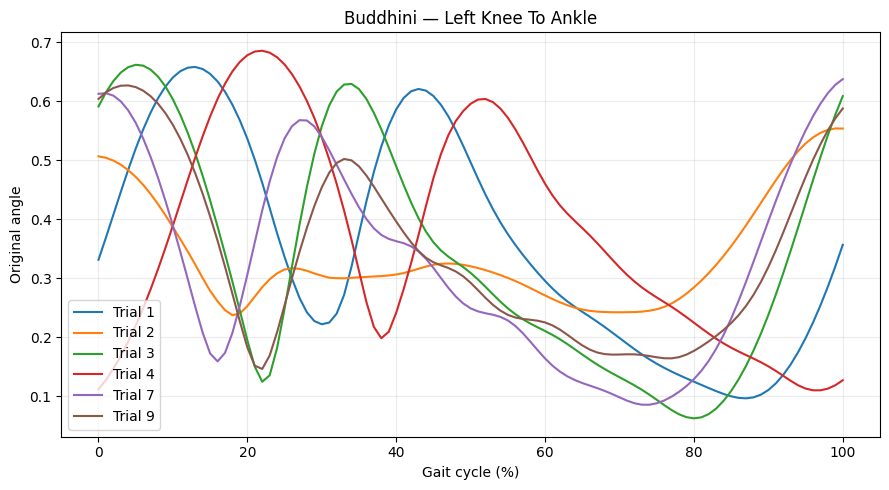

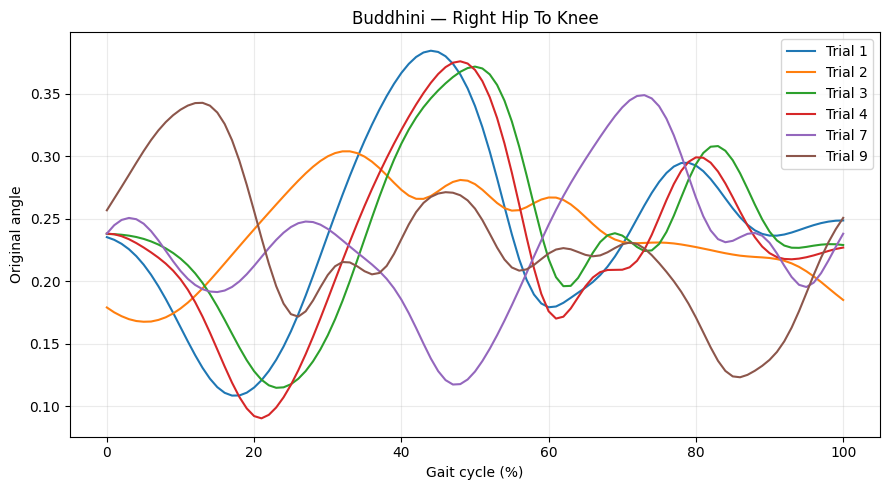

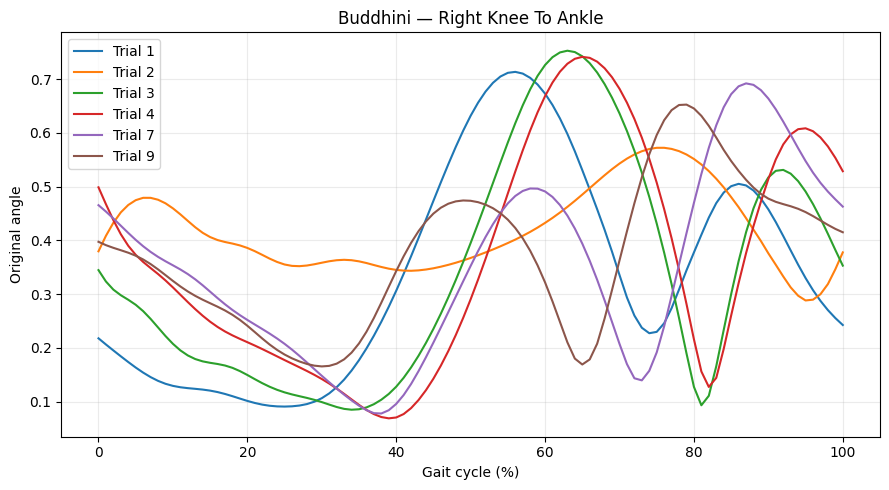

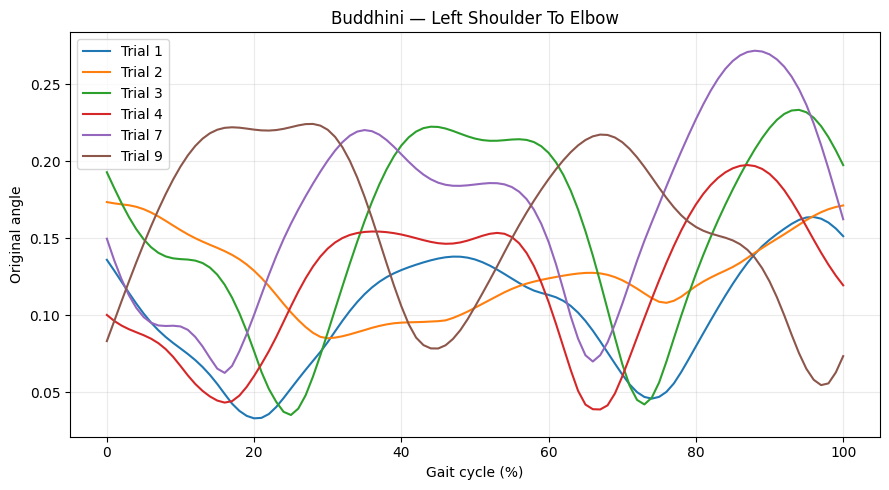

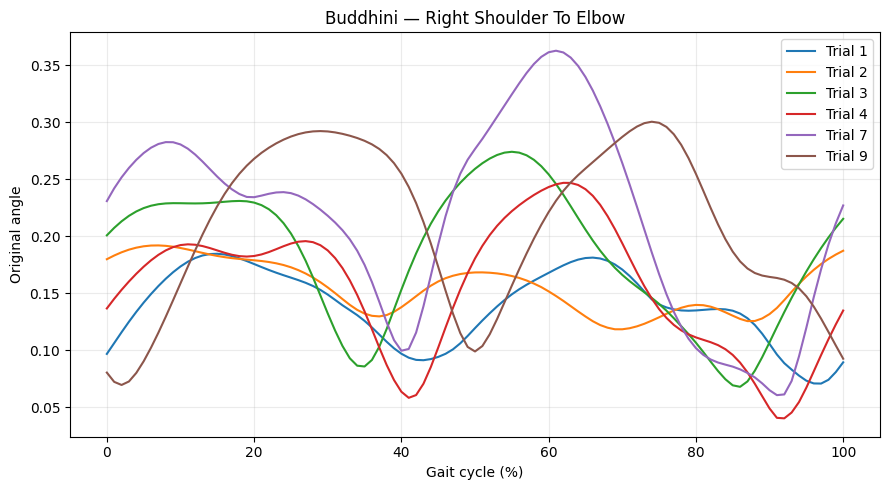

In [7]:
# CELL 6 — Compare several signals across trials

SIGNALS = [
    "left_hip_to_knee_original_angle",
    "left_knee_to_ankle_original_angle",
    "right_hip_to_knee_original_angle",
    "right_knee_to_ankle_original_angle",
    "left_shoulder_to_elbow_original_angle",
    "right_shoulder_to_elbow_original_angle"
]

PERSON = "Buddhini"

for signal in SIGNALS:

    plt.figure(figsize=(9, 5))

    for trial in trials:

        trial_cycles = [
            c[signal]
            for c in normalized_cycles
            if c["person"] == PERSON
            and c["trial"] == trial
        ]

        if not trial_cycles:
            continue

        mean_waveform = np.vstack(
            trial_cycles
        ).mean(axis=0)

        plt.plot(
            target_percent,
            mean_waveform,
            label=f"Trial {trial}"
        )

    nice_name = (
        signal
        .replace("_original_angle", "")
        .replace("_", " ")
        .title()
    )

    plt.title(
        f"{PERSON} — {nice_name}"
    )

    plt.xlabel("Gait cycle (%)")
    plt.ylabel("Original angle")

    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

There is repeatability, but it is signal-dependent, and there is also substantial between-trial variation. I would not treat Buddhini's gait as one fixed waveform.

The most interesting result is in the lower-limb signals. For right hip-to-knee, Trials 1, 3, and 4 are strikingly similar: trough around ~20–25%, large peak around ~45–50%, another low region around ~60%, and a smaller peak around ~80%. That's much stronger repeatability than we saw in some of the arm signals. Trial 7 appears partly phase-shifted, while Trial 9 differs considerably. Right knee-to-ankle also shows shared structure—particularly Trials 1, 3, and 4—but the timing and magnitude of the later peaks vary substantially.

The shoulder-to-elbow signals are much less stable. Both left and right sides show large changes in peak timing and amplitude between trials. That is plausible: arm swing can vary more between walking sessions because of walking speed, intentional/unintentional arm movement, posture, sensor estimation, and other recording effects. At this stage, though, the plots alone cannot tell us which cause is responsible.
There is also evidence suggesting a phase/alignment problem may contribute. Some trials have recognizable shapes occurring at different percentages of the normalized cycle. Normalizing every cycle to 0–100% fixes duration, but it does not guarantee biomechanical alignment. If two cycles begin at different physical events, interpolation won't fix that—it just stretches both to the same length.

 summarize:
Some lower-limb waveform characteristics appear repeatable across independent trials, particularly Trials 1, 3, and 4, while other trials and upper-limb signals show substantial variability. Further cycle-level and alignment analysis is required before interpreting these differences as person-specific gait characteristics.

Mean ± standard deviation for each trial

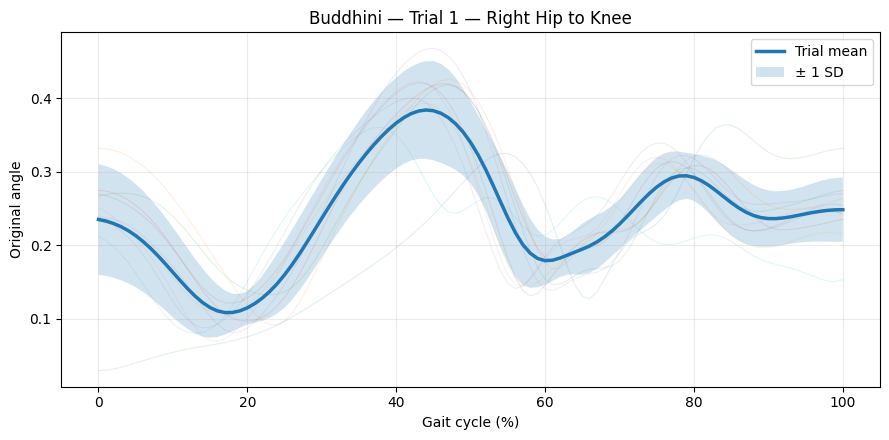

Trial 1: 10 cycles


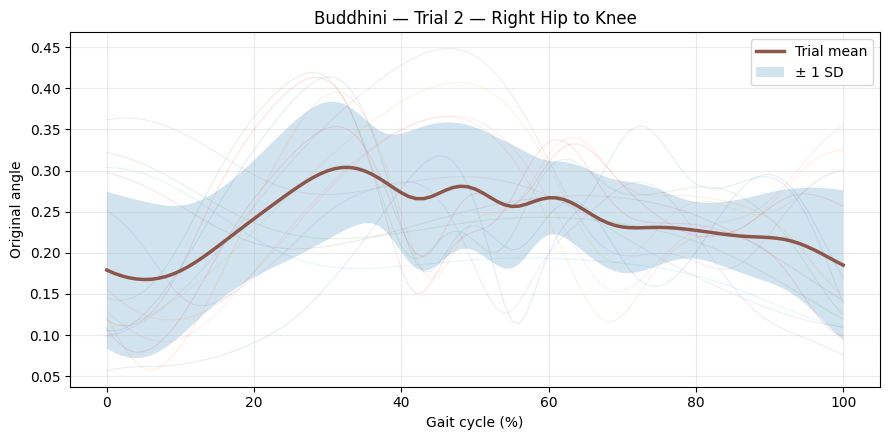

Trial 2: 15 cycles


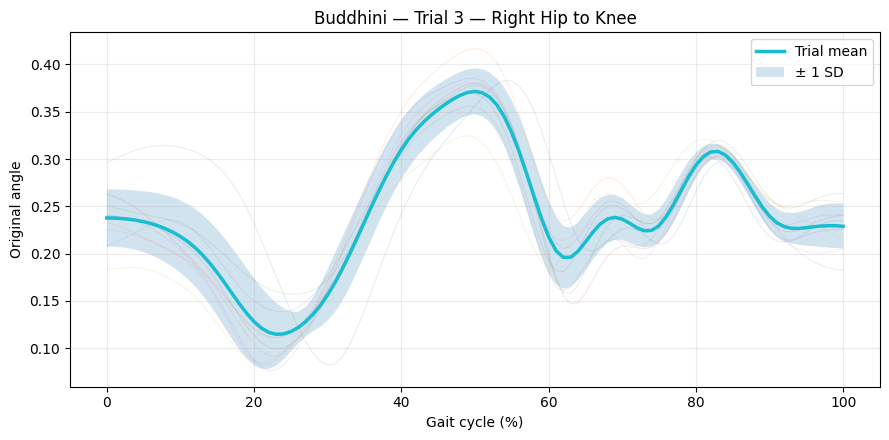

Trial 3: 9 cycles


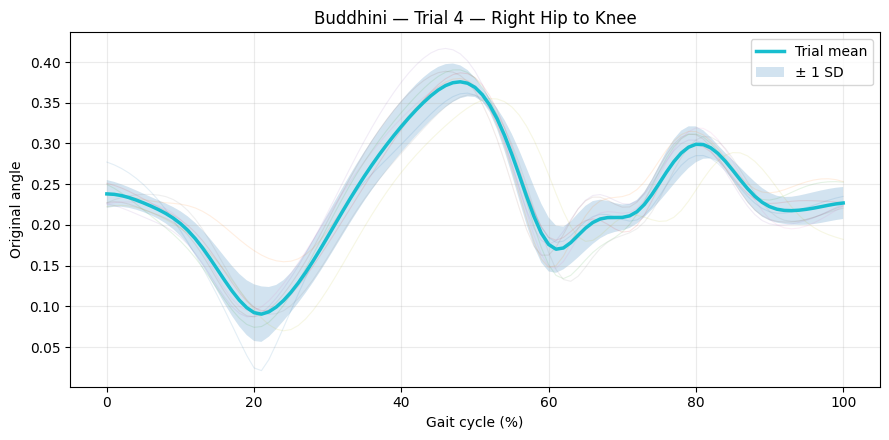

Trial 4: 9 cycles


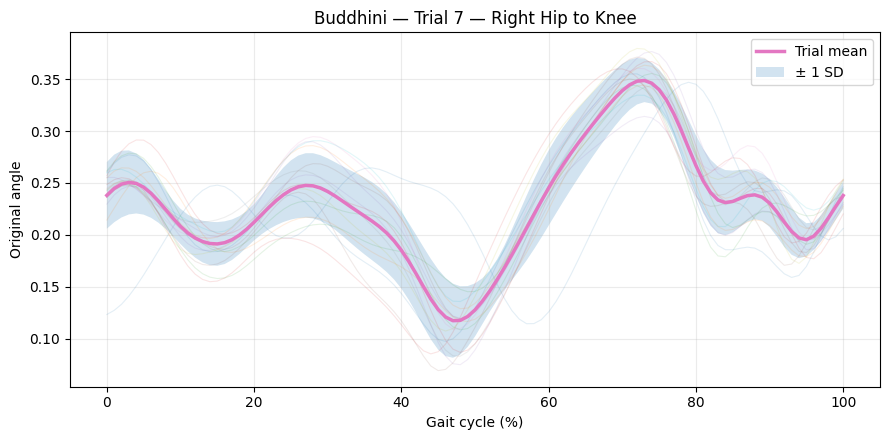

Trial 7: 16 cycles


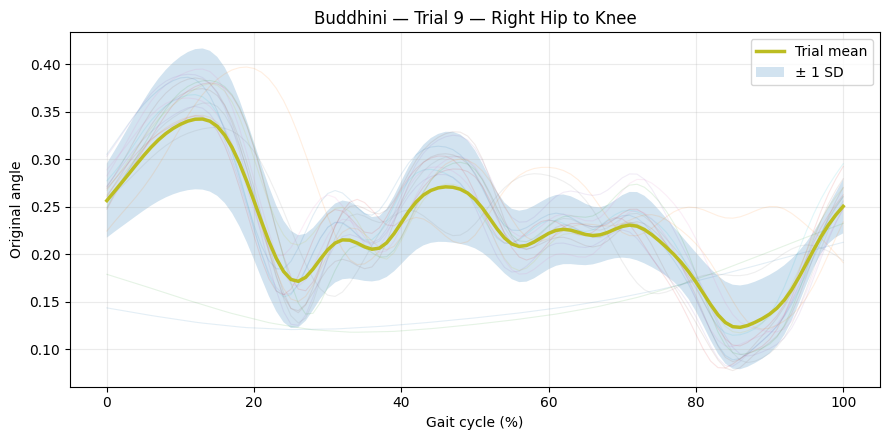

Trial 9: 18 cycles


In [8]:
# CELL 7 — Within-trial variability
# Mean waveform ± 1 standard deviation

PERSON = "Buddhini"
SIGNAL = "right_hip_to_knee_original_angle"

trials = sorted(
    set(
        c["trial"]
        for c in normalized_cycles
        if c["person"] == PERSON
    ),
    key=int
)

for trial in trials:

    trial_cycles = [
        c[SIGNAL]
        for c in normalized_cycles
        if c["person"] == PERSON
        and c["trial"] == trial
    ]

    if not trial_cycles:
        continue

    X = np.vstack(trial_cycles)

    mean_waveform = X.mean(axis=0)
    std_waveform = X.std(axis=0)

    plt.figure(figsize=(9, 4.5))

    # Individual cycles
    for cycle in X:
        plt.plot(
            target_percent,
            cycle,
            alpha=0.12,
            linewidth=0.8
        )

    # Trial mean
    plt.plot(
        target_percent,
        mean_waveform,
        linewidth=2.5,
        label="Trial mean"
    )

    # ± 1 SD
    plt.fill_between(
        target_percent,
        mean_waveform - std_waveform,
        mean_waveform + std_waveform,
        alpha=0.2,
        label="± 1 SD"
    )

    plt.title(
        f"{PERSON} — Trial {trial} — Right Hip to Knee"
    )

    plt.xlabel("Gait cycle (%)")
    plt.ylabel("Original angle")

    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(
        f"Trial {trial}: {len(X)} cycles"
    )

LOW variation within a trial
+ LOW variation between trials
→ excellent candidate for person-specific gait information

LOW variation within a trial
+ HIGH variation between trials
→ likely session/trial effect

HIGH variation within a trial
→ signal itself may be unstable/noisy or gait varies cycle-to-cycle

These show that we actually have two different kinds of variation in Buddhini's data.

What the plots show
Trials 3 and 4 are excellent. Their individual cycles are tightly clustered around the mean, the ±1 SD band is narrow for most of the gait cycle, and their mean waveforms are extremely similar. Both have the same major structure: decrease around 0–20%, strong rise to a peak around 45–50%, sharp decrease around 55–65%, secondary peak around ~80%, then stabilization.

Trial 1 is also fairly consistent. Its mean shape resembles Trials 3 and 4 strongly. There are a couple of unusual individual cycles, but most cycles cluster around the mean. So Trials 1, 3, and 4 give us quite convincing evidence of repeatability for this particular signal.

Trial 7 is internally very consistent — but different from Trials 1/3/4. This is especially interesting. Its SD band is quite narrow, meaning Trial 7 isn't simply noisy. The cycles repeatedly produce a different waveform: the major trough occurs around ~45%, followed by a large peak around ~70%.
That suggests a systematic trial/session difference, rather than random measurement noise.

Trial 9 is also reasonably structured internally, although there's more variability and what look like a few unusual cycles. Its mean is clearly different from Trials 1/3/4.

Trial 2 is the least stable-looking recording. Its individual cycles spread substantially around the mean and its SD band is much wider. The average itself is relatively flat compared with the other trials. So Trial 2 seems to contain substantial cycle-to-cycle variation.

This distinction is important:

Trials 3 & 4 → low within-trial variation + very similar between trials
Trial 1     → reasonably low variation + similar to 3/4

Trial 7     → low within-trial variation BUT different waveform
Trial 9     → structured but different waveform

Trial 2     → high within-trial variation

That's actually an important finding
Trial 7 tells us something particularly useful.
If the difference were simply random noise, we'd expect the individual cycles within Trial 7 to be all over the place.

They're not.
They're clustered around a different mean waveform.
So there may be a trial/session effect. Possible explanations include different walking behavior/speed, recording configuration, orientation/reference-frame changes, cycle boundary alignment, or another systematic acquisition difference. We can't determine which one from these plots alone.
And this reinforces why random cycle splitting would be dangerous. If the model trains on some Trial 7 cycles and tests on other Trial 7 cycles, classification could be easy because those cycles are highly similar. But recognizing Buddhini when Trial 7 is completely unseen is a much harder—and much more meaningful—test.

Now let's quantify this
We've reached the point where looking at more plots manually will get messy. You have 18 signals × 22 independent trials × 435 cycles.
Let's calculate waveform similarity objectively.
For each signal we'll compare trial-average waveforms using Pearson correlation. A correlation near 1 means two waveforms have very similar shapes, 0 means little linear shape similarity, and negative values indicate opposing patterns.

Build one mean waveform per trial

In [9]:
# CELL 8 — Create trial-level mean waveforms

trial_waveforms = {}

for person in PEOPLE:

    person_trials = sorted(
        set(
            c["trial"]
            for c in normalized_cycles
            if c["person"] == person
        ),
        key=int
    )

    for trial in person_trials:

        trial_cycles = [
            c
            for c in normalized_cycles
            if c["person"] == person
            and c["trial"] == trial
        ]

        trial_waveforms[(person, trial)] = {}

        for signal in ORIGINAL_ANGLE_COLS:

            X = np.vstack([
                c[signal]
                for c in trial_cycles
            ])

            trial_waveforms[(person, trial)][signal] = (
                X.mean(axis=0)
            )

print(
    "Trial-level waveform sets:",
    len(trial_waveforms)
)

Trial-level waveform sets: 22


Buddhini trial-to-trial correlation

In [10]:
# CELL 9 — Trial-to-trial waveform correlations

SIGNAL = "right_hip_to_knee_original_angle"
PERSON = "Buddhini"

person_trials = sorted(
    [
        key
        for key in trial_waveforms
        if key[0] == PERSON
    ],
    key=lambda x: int(x[1])
)

corr_matrix = np.zeros(
    (len(person_trials), len(person_trials))
)

for i, trial_a in enumerate(person_trials):

    for j, trial_b in enumerate(person_trials):

        waveform_a = trial_waveforms[trial_a][SIGNAL]
        waveform_b = trial_waveforms[trial_b][SIGNAL]

        corr_matrix[i, j] = np.corrcoef(
            waveform_a,
            waveform_b
        )[0, 1]


corr_df = pd.DataFrame(
    corr_matrix,
    index=[
        f"Trial {t[1]}"
        for t in person_trials
    ],
    columns=[
        f"Trial {t[1]}"
        for t in person_trials
    ]
)

display(
    corr_df.round(3)
)

,Trial 1,Trial 2,Trial 3,Trial 4,Trial 7,Trial 9
Trial 1,1.000,0.375,0.790,0.919,-0.290,-0.236
Trial 2,0.375,1.000,0.092,0.188,-0.198,-0.329
Trial 3,0.790,0.092,1.000,0.955,-0.432,-0.059
Trial 4,0.919,0.188,0.955,1.000,-0.396,-0.083
Trial 7,-0.290,-0.198,-0.432,-0.396,1.000,-0.264
Trial 9,-0.236,-0.329,-0.059,-0.083,-0.264,1.000


The numbers strongly confirm what we saw visually.

For this specific Buddhini right-hip-to-knee waveform, there appears to be a clear cluster of Trials 1, 3, and 4:
- Trial 1 ↔ Trial 3: 0.790
- Trial 1 ↔ Trial 4: 0.919
- Trial 3 ↔ Trial 4: 0.955

A correlation of 0.955 between independent Trials 3 and 4 means their normalized mean waveform shapes are extremely similar. That's encouraging evidence of cross-trial repeatability for this signal.
Trial 2 is much less similar to that cluster, while Trials 7 and 9 have mostly negative correlations with the 1/3/4 group. That confirms they aren't merely slightly noisier versions of the same waveform—their mean waveform shapes are systematically different.
One subtle point: Trial 7 and Trial 9 aren't similar to each other either (r = -0.264). So we don't simply have two obvious stable gait patterns. Instead, this signal appears to have a highly repeatable 1/3/4 pattern plus several substantially different sessions.
That means we should not remove Trials 2, 7, or 9 just because they differ. Doing that would cherry-pick the easy recordings and inflate eventual classification performance. Unless we find a documented acquisition/processing fault, they remain legitimate independent trials.

Now the important question becomes:
Is this instability specific to Buddhini's right hip-to-knee signal, or does it happen across people and across the 18 signals?

Same-person vs different-person similarity for all 18 signals

In [11]:
# CELL 10 — Compare same-person vs different-person waveform similarity

from itertools import combinations

similarity_records = []

trial_keys = list(trial_waveforms.keys())

for signal in ORIGINAL_ANGLE_COLS:

    for key_a, key_b in combinations(trial_keys, 2):

        person_a, trial_a = key_a
        person_b, trial_b = key_b

        waveform_a = trial_waveforms[key_a][signal]
        waveform_b = trial_waveforms[key_b][signal]

        correlation = np.corrcoef(
            waveform_a,
            waveform_b
        )[0, 1]

        comparison_type = (
            "same_person"
            if person_a == person_b
            else "different_person"
        )

        similarity_records.append({
            "signal": signal,
            "person_a": person_a,
            "trial_a": trial_a,
            "person_b": person_b,
            "trial_b": trial_b,
            "comparison": comparison_type,
            "correlation": correlation
        })


similarity_df = pd.DataFrame(similarity_records)

print("Total comparisons:", len(similarity_df))

display(similarity_df.head())

Total comparisons: 4158


,signal,person_a,trial_a,person_b,trial_b,comparison,correlation
0,left_ankle_to_foot_original_angle,Buddhini,1,Buddhini,2,same_person,0.047580
1,left_ankle_to_foot_original_angle,Buddhini,1,Buddhini,3,same_person,0.411110
2,left_ankle_to_foot_original_angle,Buddhini,1,Buddhini,4,same_person,0.265550
3,left_ankle_to_foot_original_angle,Buddhini,1,Buddhini,7,same_person,0.826691
4,left_ankle_to_foot_original_angle,Buddhini,1,Buddhini,9,same_person,0.314763


In [12]:
# CELL 11 — Average similarity by signal

signal_similarity = (
    similarity_df
    .groupby(["signal", "comparison"])
    ["correlation"]
    .agg(["mean", "median", "std", "count"])
    .reset_index()
)

summary = signal_similarity.pivot(
    index="signal",
    columns="comparison",
    values="mean"
)

summary["difference"] = (
    summary["same_person"]
    - summary["different_person"]
)

summary = summary.sort_values(
    "difference",
    ascending=False
)

display(summary.round(3))

comparison,different_person,same_person,difference
signal,,,
left_elbow_to_wrist_original_angle,-0.087,0.384,0.471
left_wrist_to_hand_original_angle,-0.089,0.369,0.458
neck_to_left_shoulder_original_angle,-0.069,0.386,0.455
neck_to_right_shoulder_original_angle,-0.062,0.370,0.432
right_elbow_to_wrist_original_angle,0.118,0.417,0.299
right_wrist_to_hand_original_angle,0.130,0.425,0.295
mid_to_upper_spine_original_angle,-0.036,0.242,0.278
left_hip_to_knee_original_angle,0.138,0.330,0.193
right_knee_to_ankle_original_angle,0.208,0.364,0.156


In [13]:
# CELL 12 — Overall same-person vs different-person similarity

overall_similarity = (
    similarity_df
    .groupby("comparison")["correlation"]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
)

display(overall_similarity.round(3))

,count,mean,median,std,min,max
comparison,,,,,,
different_person,3438,0.091,0.063,0.499,-0.899,0.996
same_person,720,0.282,0.365,0.508,-0.858,0.999


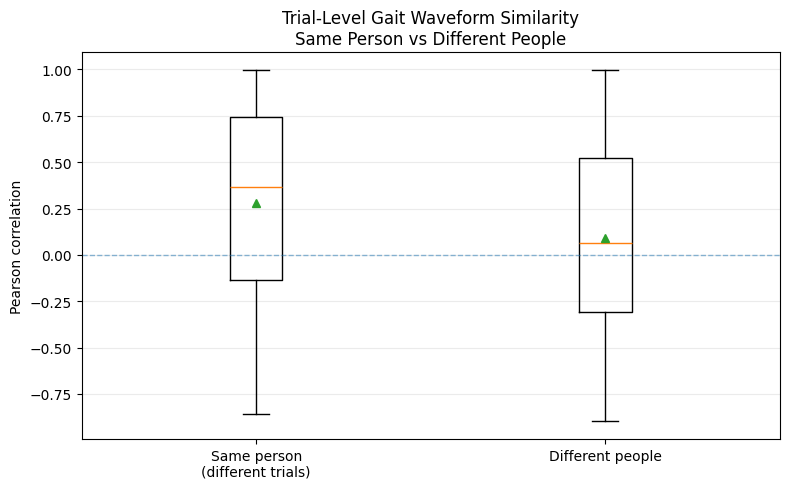

In [14]:
# CELL 13 — Distribution of waveform similarity

same = similarity_df.loc[
    similarity_df["comparison"] == "same_person",
    "correlation"
]

different = similarity_df.loc[
    similarity_df["comparison"] == "different_person",
    "correlation"
]

plt.figure(figsize=(8, 5))

plt.boxplot(
    [same, different],
    tick_labels=[
        "Same person\n(different trials)",
        "Different people"
    ],
    showmeans=True
)

plt.ylabel("Pearson correlation")
plt.title(
    "Trial-Level Gait Waveform Similarity\n"
    "Same Person vs Different People"
)

plt.axhline(
    0,
    linewidth=1,
    linestyle="--",
    alpha=0.5
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()

The key observation is that the same-person distribution is shifted upward. Its median is about 0.365 and mean about 0.282, while different-person comparisons have median 0.063 and mean 0.091. So independent recordings from the same person tend, on average, to have more similar waveform shapes.
However, there is substantial overlap between the boxes and whiskers. Some different-person trials are highly similar, while some same-person trials are negatively correlated. Therefore, waveform correlation by itself is clearly not sufficient to identify a person reliably.

A good research interpretation would be:
Trial-level waveform analysis showed greater average similarity between independent recordings of the same participant than between different participants. However, substantial overlap between the two distributions indicates considerable intra-person variability and inter-person similarity. These findings suggest that individual gait characteristics are present in the recorded signals, but identification is likely to require information from multiple gait signals and features rather than waveform similarity alone.